# AirQualityUCI baselines (BB vs VAR/VARX vs SARIMAX)

This notebook reproduces the **final baseline comparison figure** used in the paper:
- **BB**: VAE decoder + controlled latent neural ODE rollout (pretrained weights loaded from disk)
- **VAR(1)** and **VARX(1)+controls**: trained by ridge regression on the training split
- **SARIMAX**: per-channel SARIMAX with exogenous controls (trained on the training split), **saved to disk** for fast reruns
- **Persistence**: last-observation carried forward

## Expected files (relative paths)
This notebook assumes the same directory structure used in the original experiments, e.g.

```
preproc/linearinterppreimp_dropNMHC/
  AQ_Xnorm_linear_dropNMHC_postVAE_nocontrol_iter20_AQ251201004.csv
  AQ_MASK_linear_dropNMHC.csv
  AQ_time_index_map_dropNMHC.csv
  vae_window3_linear9_dropNMHC_nocontrol_bundle_AQ251201004.pt
  latentODE_window3_dropNMHC_nocontrol_H128x3_CTRL_AQ251201010.pt
preproc/AQ_splits_fixed.npz
```

If your paths differ, edit `ROOT_DIR` and/or `BASE_DIR` in the loading cell.



In [1]:
# ==========================
# BOOTSTRAP: load AQ post-VAE csv + mask + time map + splits + VAE + latent ODE
# (copied from Untitled7.ipynb, with a small "auto-find BASE_DIR" fallback)
# ==========================
import os, math
import numpy as np
import pandas as pd
import torch
from torch import nn
from torchdiffeq import odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def find_base_dir():
    """
    Tries to find preproc/linearinterppreimp_dropNMHC starting from cwd and going up.
    """
    here = os.getcwd()
    candidates = []
    # search up to 6 levels up
    cur = here
    for _ in range(7):
        cand = os.path.join(cur, "preproc", "linearinterppreimp_dropNMHC")
        candidates.append(cand)
        cur = os.path.dirname(cur)
    for c in candidates:
        if os.path.isdir(c):
            return c
    raise FileNotFoundError(
        "Cannot find folder preproc/linearinterppreimp_dropNMHC. "
        "cd to your project root (where ./preproc exists), then rerun."
    )

ROOT_DIR = os.getcwd()
BASE_DIR = os.path.join(ROOT_DIR, "preproc", "linearinterppreimp_dropNMHC")
if not os.path.isdir(BASE_DIR):
    BASE_DIR = find_base_dir()
    ROOT_DIR = os.path.dirname(os.path.dirname(BASE_DIR))
print("ROOT_DIR:", ROOT_DIR)
print("BASE_DIR:", BASE_DIR)

X_post_path  = os.path.join(BASE_DIR, "AQ_Xnorm_linear_dropNMHC_postVAE_nocontrol_iter20_AQ251201004.csv")
MASK_path    = os.path.join(BASE_DIR, "AQ_MASK_linear_dropNMHC.csv")
time_map_csv = os.path.join(BASE_DIR, "AQ_time_index_map_dropNMHC.csv")

VAE_BUNDLE   = os.path.join(BASE_DIR, "vae_window3_linear9_dropNMHC_nocontrol_bundle_AQ251201004.pt")
ODE_CKPT     = os.path.join(BASE_DIR, "latentODE_window3_dropNMHC_nocontrol_H128x3_CTRL_AQ251201010.pt")

splits_path  = os.path.join(ROOT_DIR, "preproc", "AQ_splits_fixed.npz")

for p in [X_post_path, MASK_path, time_map_csv, VAE_BUNDLE, ODE_CKPT, splits_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

print("Loading CSVs...")
X_post_df = pd.read_csv(X_post_path)
MASK_df   = pd.read_csv(MASK_path)
time_df   = pd.read_csv(time_map_csv, parse_dates=["DateTime"])
time_df_idx = time_df.set_index("t_idx")

t_idx     = X_post_df.iloc[:, 0].to_numpy(dtype=np.int64)
X_full    = X_post_df.iloc[:, 1:].to_numpy(dtype=np.float32)   # (N,12)
MASK_full = MASK_df.to_numpy(dtype=np.float32)                 # (N,12)
N, D_full = X_full.shape
print("N, D_full:", N, D_full)

pollutant_idx = np.arange(0, 9)
meteo_idx     = np.arange(9, 12)

X_poll_norm  = X_full[:, pollutant_idx]        # (N,9)
X_meteo_norm = X_full[:, meteo_idx]            # (N,3)
MASK_poll    = MASK_full[:, pollutant_idx]     # (N,9)

poll_names = [
    "CO_GT_", "PT08_S1_CO_", "C6H6_GT_", "PT08_S2_NMHC_", "NOx_GT_",
    "PT08_S3_NOx_", "NO2_GT_", "PT08_S4_NO2_", "PT08_S5_O3_",
]

print("Loading splits...")
splits = np.load(splits_path)
idx_train = splits["idx_train"]
idx_val   = splits["idx_val"]
idx_test1 = splits["idx_test1"]
idx_test2 = splits["idx_test2"]
print("Point-level split sizes:", len(idx_train), len(idx_val), len(idx_test1), len(idx_test2))

def build_window_centers(t_idx_arr, idx_centers, window_len=3):
    assert window_len == 3
    idx_centers = np.asarray(idx_centers, dtype=int)
    valid = []
    Nloc = len(t_idx_arr)
    for i in idx_centers:
        i_prev = i - 1
        i_next = i + 1
        if i_prev < 0 or i_next >= Nloc:
            continue
        if (t_idx_arr[i] - t_idx_arr[i_prev] != 1) or (t_idx_arr[i_next] - t_idx_arr[i] != 1):
            continue
        valid.append(i)
    return np.array(valid, dtype=int)

win_train_centers = build_window_centers(t_idx, idx_train)
win_val_centers   = build_window_centers(t_idx, idx_val)
win_test1_centers = build_window_centers(t_idx, idx_test1)
win_test2_centers = build_window_centers(t_idx, idx_test2)
win_all_centers   = build_window_centers(t_idx, np.arange(N))

print("Window centers:",
      "train", len(win_train_centers),
      "val", len(win_val_centers),
      "test1", len(win_test1_centers),
      "test2", len(win_test2_centers),
      "all", len(win_all_centers))

print("Building controls U_full...")
hour_of_day = time_df_idx.loc[t_idx, "HourOfDay"].to_numpy(dtype=np.float32)
dow         = time_df_idx.loc[t_idx, "DayOfWeek"].to_numpy(dtype=np.float32)
is_weekend  = time_df_idx.loc[t_idx, "IsWeekend"].to_numpy(dtype=np.float32)

hour_norm = hour_of_day / 24.0
hour_sin  = np.sin(2.0 * np.pi * hour_norm)
hour_cos  = np.cos(2.0 * np.pi * hour_norm)

dow_norm = (dow - 1.0) / 7.0
dow_sin  = np.sin(2.0 * np.pi * dow_norm)
dow_cos  = np.cos(2.0 * np.pi * dow_norm)

U_full = np.concatenate(
    [
        X_meteo_norm, hour_sin[:, None], hour_cos[:, None],
        dow_sin[:, None], dow_cos[:, None], is_weekend[:, None]
    ],
    axis=1
).astype(np.float32)

CONTROL_DIM = U_full.shape[1]
print("U_full:", U_full.shape, "CONTROL_DIM:", CONTROL_DIM)

def torch_load_compat(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

print("Loading VAE bundle...")
bundle = torch_load_compat(VAE_BUNDLE, map_location=device)
arch = bundle["arch"]
latent_dim = int(arch["latent_dim"])
hidden_dim = int(arch["hidden_dim"])
center_dim = int(arch["center_dim"])   # should be 9
input_dim  = int(arch["input_dim"])    # should be 27
print("VAE arch:", arch)

class Window3VAE_NoControl(nn.Module):
    def __init__(self, in_dim_flat, center_dim, latent_dim, hidden_dim):
        super().__init__()
        Act = nn.GELU
        self.encoder = nn.Sequential(
            nn.Linear(in_dim_flat, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
        )
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder   = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, center_dim),
        )

    def encode(self, x_flat):
        h = self.encoder(x_flat)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        return self.decoder(z)

vae = Window3VAE_NoControl(input_dim, center_dim, latent_dim, hidden_dim).to(device)
vae.load_state_dict(bundle["model_state"])
vae.eval()
print("VAE loaded.")

def centers_to_flat_windows(centers, X_poll):
    centers = np.asarray(centers, dtype=int)
    w = np.stack([X_poll[centers-1], X_poll[centers], X_poll[centers+1]], axis=1)  # (K,3,9)
    return w.reshape(len(centers), -1).astype(np.float32)                          # (K,27)

@torch.no_grad()
def encode_decode_centers_batched(centers, batch_size=8192):
    Xflat = centers_to_flat_windows(centers, X_poll_norm)
    Z_out = []
    C_out = []
    for s in range(0, len(centers), batch_size):
        xb = torch.from_numpy(Xflat[s:s+batch_size]).to(device)
        mu, _ = vae.encode(xb)
        cb = vae.decode(mu)
        Z_out.append(mu.detach().cpu().numpy())
        C_out.append(cb.detach().cpu().numpy())
    return np.concatenate(Z_out, axis=0), np.concatenate(C_out, axis=0)

print("Precomputing Z_all / Chat_all for all centers...")
Z_all, Chat_all = encode_decode_centers_batched(win_all_centers, batch_size=8192)
center_to_pos = {int(c): i for i, c in enumerate(win_all_centers)}
print("Z_all:", Z_all.shape, "Chat_all:", Chat_all.shape)

def decode_latents(z_batch_torch):
    if z_batch_torch.ndim == 2:
        return vae.decode(z_batch_torch)
    B, T, Dz = z_batch_torch.shape
    zf = z_batch_torch.reshape(B*T, Dz)
    xf = vae.decode(zf)
    return xf.view(B, T, center_dim)

print("Loading latent ODE...")
state = torch_load_compat(ODE_CKPT, map_location=device)
arch_ode = state["arch"]
LATENT_DIM = int(arch_ode["latent_dim"])
HIDDEN_DIM = int(arch_ode["hidden_dim"])
T_HORIZON  = float(arch_ode["t_horizon"])
print("ODE arch:", arch_ode)

class LatentODEFunc(nn.Module):
    def __init__(self, latent_dim, control_dim, hidden_dim=128, t_horizon=3.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.control_dim = control_dim
        self.t_horizon = float(t_horizon)
        self.t_horizon_int = int(round(t_horizon))
        Act = nn.Tanh
        self.net = nn.Sequential(
            nn.Linear(latent_dim + control_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, t, z, u_seq):
        t_val = float(torch.clamp(t, 0.0, self.t_horizon).item())
        if t_val <= 0:
            k0 = k1 = 0; alpha = 0.0
        elif t_val >= self.t_horizon:
            k0 = k1 = self.t_horizon_int; alpha = 0.0
        else:
            k0 = int(math.floor(t_val))
            k1 = k0 + 1
            alpha = t_val - k0

        k0 = max(0, min(k0, 3))
        k1 = max(0, min(k1, 3))
        u0 = u_seq[:, k0, :]
        u1 = u_seq[:, k1, :]
        u  = (1.0 - alpha) * u0 + alpha * u1
        return self.net(torch.cat([z, u], dim=-1))

ode_func = LatentODEFunc(
    latent_dim=LATENT_DIM,
    control_dim=CONTROL_DIM,
    hidden_dim=HIDDEN_DIM,
    t_horizon=T_HORIZON,
).to(device)
ode_func.load_state_dict(state["ode_state"])
ode_func.eval()
print("Neural ODE loaded.")


Using device: cpu
ROOT_DIR: /Users/duanx3/Documents/airqualityUCI
BASE_DIR: /Users/duanx3/Documents/airqualityUCI/preproc/linearinterppreimp_dropNMHC
Loading CSVs...
N, D_full: 9325 12
Loading splits...
Point-level split sizes: 6292 1348 336 1349
Window centers: train 6291 val 1348 test1 336 test2 1348 all 9323
Building controls U_full...
U_full: (9325, 8) CONTROL_DIM: 8
Loading VAE bundle...
VAE arch: {'variant': 'no_control', 'input_dim': 27, 'center_dim': 9, 'latent_dim': 2, 'hidden_dim': 256, 'beta': 0.05}
VAE loaded.
Precomputing Z_all / Chat_all for all centers...
Z_all: (9323, 2) Chat_all: (9323, 9)
Loading latent ODE...
ODE arch: {'latent_dim': 2, 'control_dim': 8, 'hidden_dim': 128, 'num_hidden_layers': 3, 't_eval': [0.0, 1.0, 2.0, 3.0], 't_horizon': 3.0}
Neural ODE loaded.


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint

# --------------------------
# Plot style tuned for paper
# --------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,  # embed fonts
    "ps.fonttype": 42,
})

# --------------------------
# Utilities
# --------------------------
def _is_consecutive_hours(start, H, t_idx):
    if start < 0 or start + H >= len(t_idx):
        return False
    seg = t_idx[start:start+H+1]
    return np.all(np.diff(seg) == 1)

def pick_eval_starts(split_centers, H, stride, cap, t_idx, center_to_pos):
    cand = np.asarray(split_centers, dtype=int)[::stride]
    out = []
    for s in cand:
        s = int(s)
        if s not in center_to_pos:
            continue
        if _is_consecutive_hours(s, H, t_idx):
            out.append(s)
        if len(out) >= cap:
            break
    return np.asarray(out, dtype=int)

def fit_var_and_varx(X_poll_norm, U_full, t_idx, idx_train, ridge=1e-6):
    N, D = X_poll_norm.shape
    Du = U_full.shape[1]
    train_mask = np.zeros(N, dtype=bool)
    train_mask[idx_train.astype(int)] = True
    good_pair = train_mask[:-1] & train_mask[1:] & ((t_idx[1:] - t_idx[:-1]) == 1)

    Xt = X_poll_norm[:-1][good_pair].astype(np.float64)   # (M,D)
    Y  = X_poll_norm[1:][good_pair].astype(np.float64)    # (M,D)
    Ut = U_full[:-1][good_pair].astype(np.float64)        # (M,Du)

    # VARX: Y = [X,U,1] W
    Phi_x = np.concatenate([Xt, np.ones((Xt.shape[0],1))], axis=1)              # (M,D+1)
    Phi_xu = np.concatenate([Xt, Ut, np.ones((Xt.shape[0],1))], axis=1)         # (M,D+Du+1)

    Gx  = Phi_x.T  @ Phi_x  + ridge * np.eye(Phi_x.shape[1])
    Gxu = Phi_xu.T @ Phi_xu + ridge * np.eye(Phi_xu.shape[1])

    Wx  = np.linalg.solve(Gx,  Phi_x.T  @ Y)                                    # (D+1, D)
    Wxu = np.linalg.solve(Gxu, Phi_xu.T @ Y)                                    # (D+Du+1, D)

    A_var = Wx[:D].T
    b_var = Wx[D].reshape(-1)

    A_varx = Wxu[:D].T
    B_varx = Wxu[D:D+Du].T
    b_varx = Wxu[D+Du].reshape(-1)

    return (A_var, b_var), (A_varx, B_varx, b_varx)

def forecast_persistence(X_poll_norm, starts, H):
    x0 = X_poll_norm[starts]
    return np.repeat(x0[:, None, :], H, axis=1)  # predicts t+1..t+H same as x0

def forecast_var(X_poll_norm, starts, H, A, b):
    D = X_poll_norm.shape[1]
    Bn = len(starts)
    out = np.zeros((Bn, H, D), dtype=np.float64)
    x = X_poll_norm[starts].astype(np.float64)
    for k in range(H):
        x = (x @ A.T) + b[None, :]
        out[:, k, :] = x
    return out.astype(np.float32)

def forecast_varx(X_poll_norm, U_full, starts, H, A, Bmat, b):
    D = X_poll_norm.shape[1]
    Bn = len(starts)
    out = np.zeros((Bn, H, D), dtype=np.float64)
    x = X_poll_norm[starts].astype(np.float64)
    for k in range(H):
        u = U_full[starts + k].astype(np.float64)  # u(t) for x(t)->x(t+1)
        x = (x @ A.T) + (u @ Bmat.T) + b[None, :]
        out[:, k, :] = x
    return out.astype(np.float32)

@torch.no_grad()
def bb_forecast_batch(starts, H, Z_all, center_to_pos, U_full, t_idx, ode_func, decode_latents, device):
    """
    Predict pollutants at t+1..t+H for each start.
    Returns (B,H,D)
    """
    starts = np.asarray(starts, dtype=int)
    N = len(t_idx)
    pos = np.array([center_to_pos[int(s)] for s in starts], dtype=int)
    z = torch.from_numpy(Z_all[pos]).to(device=device, dtype=torch.float32)

    preds = []
    cur_t = starts.copy()
    remaining = H

    while remaining > 0:
        seg = int(min(3, remaining))

        idx0 = np.clip(cur_t + 0, 0, N-1)
        idx1 = np.clip(cur_t + 1, 0, N-1)
        idx2 = np.clip(cur_t + 2, 0, N-1)
        idx3 = np.clip(cur_t + 3, 0, N-1)
        u_seq_np = np.stack([U_full[idx0], U_full[idx1], U_full[idx2], U_full[idx3]], axis=1)
        u_seq = torch.from_numpy(u_seq_np).to(device=device, dtype=torch.float32)

        t_points = torch.linspace(0.0, float(seg), seg + 1, device=device)

        def rhs(t, zstate):
            return ode_func(t, zstate, u_seq)

        z_traj = odeint(rhs, z, t_points, method="dopri5")  # (seg+1,B,Dz)
        z_steps = z_traj[1:]                                # (seg,B,Dz)
        z = z_traj[-1]                                      # (B,Dz)

        x_steps = decode_latents(z_steps.permute(1, 0, 2)).detach().cpu().numpy()  # (B,seg,D)
        preds.append(x_steps.astype(np.float32))

        cur_t = cur_t + seg
        remaining -= seg

    return np.concatenate(preds, axis=1)

def mse_curve_masked(pred_BHD, starts, H, X_poll_norm, MASK_poll):
    """
    pred_BHD predicts t+1..t+H
    Returns mean and SEM over starts (each start -> mean over measured dims).
    """
    Bn = len(starts)
    means = np.zeros(H, dtype=np.float64)
    sems  = np.zeros(H, dtype=np.float64)

    for h in range(1, H+1):
        tgt = starts + h
        y_true = X_poll_norm[tgt]    # (B,D)
        m      = MASK_poll[tgt]      # (B,D)
        y_pred = pred_BHD[:, h-1, :] # (B,D)

        per = []
        for i in range(Bn):
            mi = m[i].astype(bool)
            if mi.sum() == 0:
                continue
            per.append(float(((y_pred[i, mi] - y_true[i, mi])**2).mean()))
        per = np.asarray(per, dtype=np.float64)

        means[h-1] = np.nan if len(per)==0 else per.mean()
        sems[h-1]  = np.nan if len(per)==0 else per.std(ddof=1) / np.sqrt(len(per))
    return means, sems


In [3]:
import numpy as np
import torch
from torchdiffeq import odeint

# -----------------------------
# Config
# -----------------------------
SPLIT = "test1"      # "test1" or "test2"
H = 24               # forecast horizon (hours)
STRIDE_EVAL = 1
CAP = 600
RIDGE = 1e-3         # ridge for VAR/VARX fits
BB_ODE_METHOD = "dopri5"  # stable; change to "rk4" for speed if desired

# -----------------------------
# Prepare arrays
# -----------------------------
X = np.asarray(X_poll_norm, dtype=np.float32)   # (N, D=9)
M = np.asarray(MASK_poll, dtype=np.float32)     # (N, D=9)
U = np.asarray(U_full, dtype=np.float32)        # (N, Du)
t_idx_np = np.asarray(t_idx, dtype=np.int64)

# -----------------------------
# Pick evaluation starts
# -----------------------------
split_centers = win_test1_centers if SPLIT.lower() == "test1" else win_test2_centers
valid_starts = pick_eval_starts(split_centers, H=H, stride=STRIDE_EVAL, cap=CAP,
                                t_idx=t_idx_np, center_to_pos=center_to_pos)
print(f"Eval starts ({SPLIT}): {len(valid_starts)} (stride={STRIDE_EVAL}, cap={CAP})")
if len(valid_starts) == 0:
    raise RuntimeError("No valid eval starts found. Try smaller H or different SPLIT/stride.")

# -----------------------------
# Fit VAR(1) / VARX(1) on TRAIN consecutive pairs
# -----------------------------
(A_var, b_var), (A_varx, B_varx, b_varx) = fit_var_and_varx(X, U, t_idx_np, idx_train, ridge=RIDGE)
print("Fitted VAR/VARX.")

# -----------------------------
# Forecast: Persistence / VAR / VARX / BB
# -----------------------------
pred_pers = forecast_persistence(X, valid_starts, H)                            # (K,H,D)
pred_var  = forecast_var(X, valid_starts, H, A_var, b_var)                      # (K,H,D)
pred_varx = forecast_varx(X, U, valid_starts, H, A_varx, B_varx, b_varx)         # (K,H,D)

print("Forecasting BB (VAE+latent ODE)...")
pred_bb = bb_forecast_batch(valid_starts, H, Z_all, center_to_pos, U, t_idx_np,
                            ode_func, decode_latents, device)

print("Pred shapes:",
      "BB", pred_bb.shape,
      "| VARX", pred_varx.shape,
      "| VAR", pred_var.shape,
      "| PERS", pred_pers.shape)

Eval starts (test1): 327 (stride=1, cap=600)
Fitted VAR/VARX.
Forecasting BB (VAE+latent ODE)...
Pred shapes: BB (327, 24, 9) | VARX (327, 24, 9) | VAR (327, 24, 9) | PERS (327, 24, 9)


In [4]:
import os, json
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

# -----------------------------
# Config
# -----------------------------
SARIMAX_DIR = os.path.join("artifacts", "sarimax_models")
os.makedirs(SARIMAX_DIR, exist_ok=True)

SARIMAX_ORDER = (1, 0, 0)
SARIMAX_SEASONAL = (1, 0, 0, 24)   # daily seasonality for hourly data
SARIMAX_TREND = "c"
SARIMAX_MAXITER = 200

REFIT_SARIMAX = False  # set True to force refit even if saved models exist

def _sarimax_paths(d):
    return (
        os.path.join(SARIMAX_DIR, f"sarimax_dim{d}.pkl"),
        os.path.join(SARIMAX_DIR, f"sarimax_dim{d}.json"),
    )

def _make_train_endog(X, M, idx_train, dim):
    # 1D endog with NaN outside TRAIN and where mask==0.
    N = X.shape[0]
    train_mask = np.zeros(N, dtype=bool)
    train_mask[np.asarray(idx_train, dtype=int)] = True

    y = X[:, dim].astype(np.float64).copy()
    y[~train_mask] = np.nan
    y[M[:, dim] < 0.5] = np.nan
    return y

def fit_one_sarimax(y, U, order, seasonal_order, trend, maxiter):
    mod = SARIMAX(
        endog=y,
        exog=U.astype(np.float64),
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    try:
        return mod.fit(disp=False, maxiter=maxiter)
    except Exception as e:
        print(f"[SARIMAX] seasonal fit failed -> fallback non-seasonal. Error: {e}")
        mod2 = SARIMAX(
            endog=y,
            exog=U.astype(np.float64),
            order=order,
            seasonal_order=(0,0,0,0),
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        return mod2.fit(disp=False, maxiter=maxiter)

# -----------------------------
# Load if available; otherwise fit and save
# -----------------------------
X = np.asarray(X_poll_norm, dtype=np.float32)
M = np.asarray(MASK_poll, dtype=np.float32)
U = np.asarray(U_full, dtype=np.float32)

N, D = X.shape

sarimax_results = []
need_fit = REFIT_SARIMAX

if not need_fit:
    for d in range(D):
        pkl_path, meta_path = _sarimax_paths(d)
        if not (os.path.exists(pkl_path) and os.path.exists(meta_path)):
            need_fit = True
            break

if need_fit:
    print("Fitting SARIMAX models (per channel) ...")
    sarimax_results = []
    for d in range(D):
        y = _make_train_endog(X, M, idx_train, d)
        res = fit_one_sarimax(
            y=y, U=U,
            order=SARIMAX_ORDER,
            seasonal_order=SARIMAX_SEASONAL,
            trend=SARIMAX_TREND,
            maxiter=SARIMAX_MAXITER,
        )
        sarimax_results.append(res)

        # Save model + minimal metadata for reproducibility
        pkl_path, meta_path = _sarimax_paths(d)
        res.save(pkl_path)
        meta = {
            "dim": d,
            "order": list(SARIMAX_ORDER),
            "seasonal_order": list(SARIMAX_SEASONAL),
            "trend": SARIMAX_TREND,
            "maxiter": SARIMAX_MAXITER,
            "note": "statsmodels SARIMAXResults via .save() (pickle)",
        }
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=2)

    print("Saved SARIMAX models to:", SARIMAX_DIR)
else:
    print("Loading saved SARIMAX models from:", SARIMAX_DIR)
    for d in range(D):
        pkl_path, _ = _sarimax_paths(d)
        sarimax_results.append(SARIMAXResults.load(pkl_path))

print("SARIMAX ready. #models =", len(sarimax_results))

Fitting SARIMAX models (per channel) ...


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Saved SARIMAX models to: artifacts/sarimax_models
SARIMAX ready. #models = 9


In [5]:
import numpy as np

def sarimax_forecast_batch(starts, H, X, M, U, sarimax_results):
    '''
    Forecast H steps ahead for each start, per-channel SARIMAX.
    Returns preds (K, H, D). Uses history up to start (inclusive).
    '''
    starts = np.asarray(starts, dtype=int)
    K = len(starts)
    N, D = X.shape
    preds = np.zeros((K, H, D), dtype=np.float32)

    for d in range(D):
        res = sarimax_results[d]
        for i, s in enumerate(starts):
            y_hist = X[:s+1, d].astype(np.float64).copy()
            y_hist[M[:s+1, d] < 0.5] = np.nan

            exog_hist = U[:s+1].astype(np.float64)
            exog_fut  = U[s+1:s+1+H].astype(np.float64)

            applied = res.apply(endog=y_hist, exog=exog_hist, refit=False)
            fc = applied.get_forecast(steps=H, exog=exog_fut)
            preds[i, :, d] = np.asarray(fc.predicted_mean, dtype=np.float32)

    return preds

X = np.asarray(X_poll_norm, dtype=np.float32)
M = np.asarray(MASK_poll, dtype=np.float32)
U = np.asarray(U_full, dtype=np.float32)

print("Forecasting SARIMAX ... (can be slower than VAR/VARX)")
pred_sarimax = sarimax_forecast_batch(valid_starts, H, X, M, U, sarimax_results)
print("SARIMAX preds:", pred_sarimax.shape)

Forecasting SARIMAX ... (can be slower than VAR/VARX)
SARIMAX preds: (327, 24, 9)


Using K=327 forecast starts for plotting.


/var/folders/2b/j4_0xvfd2yn858rh_853wd8h9f4j83/T/ipykernel_69907/1279742307.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figs_paper/Fig_AQ_Baselines_test1_H24_CRM_SARIMAX.pdf


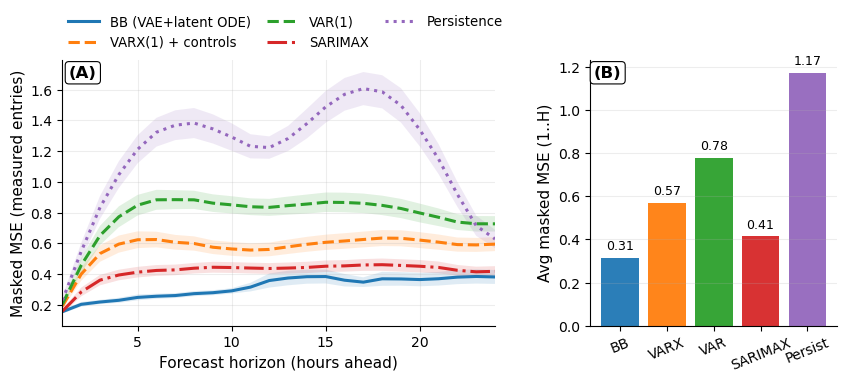

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# REQUIRED GLOBALS
# -----------------------------
required = [
    "X_poll_norm", "MASK_poll", "t_idx",
    "win_test1_centers", "win_test2_centers",
    "center_to_pos"
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run your loading cells first.")

need_preds = ["pred_bb", "pred_varx", "pred_var", "pred_pers", "pred_sarimax"]
missing_preds = [k for k in need_preds if k not in globals()]
if missing_preds:
    raise RuntimeError(
        f"Missing {missing_preds} in memory. Run forecasting cells first."
    )

# -----------------------------
# CONFIG
# -----------------------------
SPLIT = "test1"      # "test1" or "test2"
H = 24
STRIDE_EVAL = 1
CAP = 600

OUT_PDF = f"figs_paper/Fig_AQ_Baselines_{SPLIT}_H{H}_CRM_SARIMAX.pdf"
import os
os.makedirs(os.path.dirname(OUT_PDF), exist_ok=True)

BAND_MODE = "sem"    # "sem" or "iqr" or "none"
BAND_ALPHA = 0.14

PANEL_STYLE = "upper"  # "upper" -> (A)(B), "lower" -> (a)(b)
def _panel_label(i):
    if PANEL_STYLE == "lower":
        return f"({chr(ord('a')+i)})"
    return f"({chr(ord('A')+i)})"

# Paper-ish typography (still matplotlib-default, but cleaner)
plt.rcParams.update({
    "font.size": 10.5,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = np.asarray(X_poll_norm, dtype=np.float32)
M = np.asarray(MASK_poll, dtype=np.float32)
t_idx_np = np.asarray(t_idx, dtype=np.int64)

pred_bb      = np.asarray(globals()["pred_bb"],      dtype=np.float32)
pred_varx    = np.asarray(globals()["pred_varx"],    dtype=np.float32)
pred_var     = np.asarray(globals()["pred_var"],     dtype=np.float32)
pred_pers    = np.asarray(globals()["pred_pers"],    dtype=np.float32)
pred_sarimax = np.asarray(globals()["pred_sarimax"], dtype=np.float32)

# Sanity: horizon consistency
for name, arr in [("pred_bb", pred_bb), ("pred_varx", pred_varx), ("pred_var", pred_var),
                  ("pred_pers", pred_pers), ("pred_sarimax", pred_sarimax)]:
    if arr.ndim != 3:
        raise ValueError(f"{name} must be (K,H,D). Got {arr.shape}.")
    if arr.shape[1] != H:
        raise ValueError(f"{name} has shape {arr.shape} but H={H} expected.")

# -----------------------------
# Utilities
# -----------------------------
def _consecutive_hours(start, H, t_idx_np):
    return (start >= 1) and (start + H < len(t_idx_np)) and ((t_idx_np[start+H] - t_idx_np[start]) == H)

def pick_eval_starts(split_centers, H, stride, cap, t_idx_np, center_to_pos):
    cand = np.asarray(split_centers, dtype=np.int64)[::stride]
    out = []
    for s in cand:
        s = int(s)
        if s not in center_to_pos:
            continue
        if _consecutive_hours(s, H, t_idx_np):
            out.append(s)
        if len(out) >= cap:
            break
    return np.asarray(out, dtype=np.int64)

def masked_mse_per_start_per_h(pred_BHD, starts, H, X, M):
    """
    pred_BHD: (K,H,D), predicts t+1..t+H
    returns mse_ps: (K,H) masked MSE over dims at each horizon
    """
    starts = np.asarray(starts, dtype=np.int64)
    tgt = starts[:, None] + np.arange(1, H+1)[None, :]      # (K,H)
    y_true = X[tgt]                                         # (K,H,D)
    mask   = (M[tgt] > 0.5)                                 # (K,H,D)

    se = (pred_BHD - y_true) ** 2
    se = se * mask
    denom = mask.sum(axis=2) + 1e-12
    mse_ps = se.sum(axis=2) / denom
    return mse_ps

def summarize_band(mse_ps, mode="sem"):
    mean = np.nanmean(mse_ps, axis=0)
    if mode == "none":
        return mean, None, None
    if mode == "sem":
        std = np.nanstd(mse_ps, axis=0, ddof=1)
        n_eff = np.sum(~np.isnan(mse_ps), axis=0)
        sem = std / np.sqrt(np.maximum(n_eff, 1))
        return mean, mean - sem, mean + sem
    if mode == "iqr":
        q25 = np.nanpercentile(mse_ps, 25, axis=0)
        q75 = np.nanpercentile(mse_ps, 75, axis=0)
        return mean, q25, q75
    raise ValueError("mode must be one of: sem, iqr, none")

# -----------------------------
# Eval starts + ALIGN K ROBUSTLY
# -----------------------------
split_centers = win_test1_centers if SPLIT.lower() == "test1" else win_test2_centers
starts = pick_eval_starts(split_centers, H=H, stride=STRIDE_EVAL, cap=CAP,
                          t_idx_np=t_idx_np, center_to_pos=center_to_pos)

# Align K across all predictions and starts (prevents 326 vs 327 mismatch)
K = min(len(starts),
        pred_bb.shape[0], pred_varx.shape[0], pred_var.shape[0],
        pred_pers.shape[0], pred_sarimax.shape[0])

starts = starts[:K]
pred_bb      = pred_bb[:K]
pred_varx    = pred_varx[:K]
pred_var     = pred_var[:K]
pred_sarimax = pred_sarimax[:K]
pred_pers    = pred_pers[:K]

print(f"Using K={K} forecast starts for plotting.")

# -----------------------------
# Compute per-start per-horizon masked MSE
# -----------------------------
bb_ps   = masked_mse_per_start_per_h(pred_bb,      starts, H, X, M)
vx_ps   = masked_mse_per_start_per_h(pred_varx,    starts, H, X, M)
va_ps   = masked_mse_per_start_per_h(pred_var,     starts, H, X, M)
sa_ps   = masked_mse_per_start_per_h(pred_sarimax, starts, H, X, M)
pe_ps   = masked_mse_per_start_per_h(pred_pers,    starts, H, X, M)

bb_m, bb_lo, bb_hi = summarize_band(bb_ps, mode=BAND_MODE)
vx_m, vx_lo, vx_hi = summarize_band(vx_ps, mode=BAND_MODE)
va_m, va_lo, va_hi = summarize_band(va_ps, mode=BAND_MODE)
sa_m, sa_lo, sa_hi = summarize_band(sa_ps, mode=BAND_MODE)
pe_m, pe_lo, pe_hi = summarize_band(pe_ps, mode=BAND_MODE)

h_axis = np.arange(1, H+1)

# -----------------------------
# Plot (compact CRM-like 2-panel)
# -----------------------------
fig = plt.figure(figsize=(10.0, 3.45))  # wide + short, like many CRM figures
gs = fig.add_gridspec(1, 2, width_ratios=[1.75, 1.0], wspace=0.28)

ax = fig.add_subplot(gs[0, 0])
bx = fig.add_subplot(gs[0, 1])

def _panel_box(ax, label):
    ax.text(
        0.015, 0.98, label,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="black", linewidth=0.8)
    )

def draw(ax, m, lo, hi, label, ls="-", lw=2.2, marker=None):
    line, = ax.plot(h_axis, m, linestyle=ls, linewidth=lw, marker=marker, markersize=3.0, label=label)
    if lo is not None:
        ax.fill_between(h_axis, lo, hi, alpha=BAND_ALPHA)
    return line

# Curves (no markers -> less “mathy”)
l_bb = draw(ax, bb_m, bb_lo, bb_hi, "BB (VAE+latent ODE)", ls="-",  marker=None)
l_vx = draw(ax, vx_m, vx_lo, vx_hi, "VARX(1) + controls",  ls="--", marker=None)
l_va = draw(ax, va_m, va_lo, va_hi, "VAR(1)",              ls="--", marker=None)
l_sa = draw(ax, sa_m, sa_lo, sa_hi, "SARIMAX",             ls="-.", marker=None)
l_pe = draw(ax, pe_m, pe_lo, pe_hi, "Persistence",         ls=":",  marker=None)

ax.set_xlabel("Forecast horizon (hours ahead)")
ax.set_ylabel("Masked MSE (measured entries)")
ax.set_xlim(1, H)
ax.grid(True, alpha=0.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend ABOVE the axis (no occlusion), compact multi-column
handles = [l_bb, l_vx, l_va, l_sa, l_pe]
labels  = [h.get_label() for h in handles]
ax.legend(
    handles, labels,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02),
    ncol=3,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.4,
    borderaxespad=0.0
)

_panel_box(ax, _panel_label(0))

# Bar panel: use the same colors as the lines
means = [
    float(np.nanmean(bb_m)),
    float(np.nanmean(vx_m)),
    float(np.nanmean(va_m)),
    float(np.nanmean(sa_m)),
    float(np.nanmean(pe_m)),
]
bar_labels = ["BB", "VARX", "VAR", "SARIMAX", "Persist"]
bar_colors = [l.get_color() for l in handles]

bx.bar(bar_labels, means, color=bar_colors, alpha=0.95)
bx.set_ylabel("Avg masked MSE (1..H)")
bx.grid(True, axis="y", alpha=0.22)
bx.spines["top"].set_visible(False)
bx.spines["right"].set_visible(False)
bx.tick_params(axis="x", rotation=22)

# Optional: annotate values (small, unobtrusive)
ymax = max(means) if len(means) else 1.0
for i, v in enumerate(means):
    bx.text(i, v + 0.02*ymax, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

_panel_box(bx, _panel_label(1))

fig.tight_layout()
fig.savefig(OUT_PDF, bbox_inches="tight")
print("Saved:", OUT_PDF)
plt.show()